In [1]:
#LOAD DATA AND PREPROCESSING
import pandas as pd
import numpy as np
import ast

# === STEP 1: LOAD & RENAME ===
data_path = "/home/goel107/NCEMS/ANALYSIS/07_15_2025/20251023-s288c-annotated-PPI-net.pkl"
df = pd.read_pickle(data_path)

# === STEP 2: SUBSET AND CLEAN ===
selected_columns = df[[
    'node', '_wkshell', 'Y2H_wkshell',
    'degree_centrality', 'betweenness_centrality', 'eigenvector_centrality', 'closeness_centrality',
    'load_centrality', 'pagerank', 'information_centrality',
    'Y2H_degree_centrality', 'Y2H_betweenness_centrality', 'Y2H_eigenvector_centrality',
    'Y2H_closeness_centrality', 'Y2H_load_centrality', 'Y2H_pagerank', 'Y2H_information_centrality',
    'DeepTMHMM_class', 'signalP_trimmed_sequence',
    'IDR_count', 'N_aa_disordered', 'disorder_fraction',
    'is_disordered_0.05', 'is_disordered_0.10', 'is_disordered_0.15', 'is_disordered_0.20', 'is_disordered_0.25', 'is_disordered_0.30', 'is_disordered_0.35', 
    'is_disordered_0.40', 'is_disordered_0.45', 'is_disordered_0.50', 'is_disordered_0.55', 'is_disordered_0.60', 'is_disordered_0.65', 'is_disordered_0.70', 
    'is_disordered_0.75', 'is_disordered_0.80', 'is_disordered_0.85', 'is_disordered_0.90', 'is_disordered_0.95', 'is_disordered_1.00',
    'mean_plddt', 'L', 
    'Ghosh-Dill-dG', 'cagiada-dG', 'Rosetta_best_total_score', 'FoldX_best_total_energy',
    'Christiano_degradation_rate(min-1)', 'Villen_halflife_min',
    'mean_molecules_per_cell', 'median_molecules_per_cell', 'log2_TE',
    'interacting_chaperones', 'in_complex', 'Pfam_Ndomains', 
    'essential',  
    'sequence', 'structure_exists', 'sequence_matches_structure', 'meltome-melting-point'
       
]].copy()

# Multiply 'cagiada-dG' by -1 (flip sign)
selected_columns['cagiada-dG'] = pd.to_numeric(selected_columns['cagiada-dG'], errors='coerce') * -1

# Replace infinite values with NaN to allow proper cleaning
selected_columns.replace([np.inf, -np.inf], np.nan, inplace=True)

# Fix Pfam_Ndomains: replace empty/NaN with 0
selected_columns['Pfam_Ndomains'] = selected_columns['Pfam_Ndomains'].fillna(0).astype(int)

# === STEP 3: DERIVED FEATURES ===
selected_columns['Length'] = selected_columns['signalP_trimmed_sequence'].fillna('').apply(len)

# Add percentile columns for all centrality metrics
ms_centrality_cols = [
    'degree_centrality', 'betweenness_centrality', 'eigenvector_centrality',
    'closeness_centrality', 'load_centrality', 'pagerank', 'information_centrality'
]
y2h_centrality_cols = [
    'Y2H_degree_centrality', 'Y2H_betweenness_centrality', 'Y2H_eigenvector_centrality',
    'Y2H_closeness_centrality', 'Y2H_load_centrality', 'Y2H_pagerank', 'Y2H_information_centrality'
]

# Rename MS columns
ms_rename_map = {col: "MS_" + col for col in ms_centrality_cols}
selected_columns.rename(columns=ms_rename_map, inplace=True)

# Add percentiles for MS-based metrics
for col in ms_centrality_cols:
    ms_col = "MS_" + col
    selected_columns[f"{ms_col}_percentile"] = selected_columns[ms_col].rank(pct=True) * 100

# Add percentiles for Y2H-based metrics
for col in y2h_centrality_cols:
    selected_columns[f"{col}_percentile"] = selected_columns[col].rank(pct=True) * 100

# === STEP 4: ONE HOT ENCODING FOR CHAPERONES ===
def fix_list(val):
    if isinstance(val, list):
        return val
    elif isinstance(val, str):
        try:
            return ast.literal_eval(val)
        except:
            return []
    elif pd.isnull(val):
        return []
    else:
        return []

selected_columns['interacting_chaperones'] = selected_columns['interacting_chaperones'].apply(fix_list)

def chaperone_category(row):
    node = row['node']
    chaps = row['interacting_chaperones']
    if not chaps or chaps == []:
        return 'protein_is_neither_chaperone_nor_interacts'
    elif node in chaps:
        return 'protein_is_chaperone'
    else:
        return 'protein_interacts_with_chaperone'

selected_columns['chaperone_category'] = selected_columns.apply(chaperone_category, axis=1)
selected_columns['is_chaperone'] = (selected_columns['chaperone_category'] == 'protein_is_chaperone').astype(int)
selected_columns['interacts_with_chaperone'] = (selected_columns['chaperone_category'] == 'protein_interacts_with_chaperone').astype(int)
selected_columns['neither_chaperone_nor_interacts'] = (selected_columns['chaperone_category'] == 'protein_is_neither_chpaerone_nor_interacts').astype(int)

# === STEP 5: Match seq and structure nodes ===
selected_columns.info()
selected_columns = selected_columns[~selected_columns["sequence"].isna()]
print (f"Number of nodes with sequence information: {selected_columns.shape[0]}")

# record those nodes that do not have sequence information
no_seq_nodes = selected_columns[selected_columns["sequence"].isna()]
print (f"Number of nodes without sequence information: {no_seq_nodes.shape[0]}")

# remove nodes with no structure from AF2
selected_columns = selected_columns[selected_columns["structure_exists"] == 1]
print (f"Number of nodes with sequence & structure information: {selected_columns.shape[0]}")

# a small number of nodes have an AF2 structure, but its sequence does not match the sequence information from SGD - we can filter those out as well
selected_columns = selected_columns[selected_columns["sequence_matches_structure"] == True]
print (f"Number of nodes with sequence, structure, and matching information between the two: {selected_columns.shape[0]}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3927 entries, 0 to 3926
Data columns (total 80 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   node                                   3927 non-null   object 
 1   _wkshell                               3927 non-null   int64  
 2   Y2H_wkshell                            1465 non-null   float64
 3   MS_degree_centrality                   3927 non-null   float64
 4   MS_betweenness_centrality              3927 non-null   float64
 5   MS_eigenvector_centrality              3927 non-null   float64
 6   MS_closeness_centrality                3927 non-null   float64
 7   MS_load_centrality                     3927 non-null   float64
 8   MS_pagerank                            3927 non-null   float64
 9   MS_information_centrality              3927 non-null   float64
 10  Y2H_degree_centrality                  1465 non-null   float64
 11  Y2H_

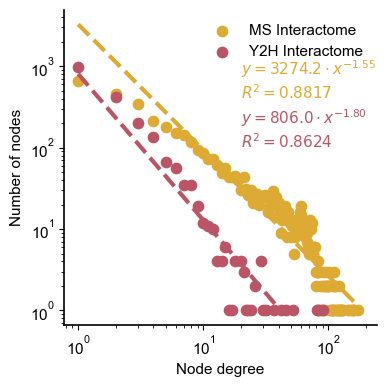

MS: slope=-1.545, intercept=3.515, R²=0.8817
Y2H: slope=-1.796, intercept=2.906, R²=0.8624


In [2]:
#Plot degree distributions from network data on a log-log scale using power-law fit (linear) 
# =============================
# 1. Import Libraries & Set Global Aesthetics
# =============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

# Publication-style font and axis settings
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['xtick.labelsize'] = 11
plt.rcParams['ytick.labelsize'] = 11
plt.rcParams['legend.fontsize'] = 11
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False

# =============================
# 2. Define File Paths
# =============================
ms_edge_path = '/home/goel107/NCEMS/ANALYSIS/07_15_2025/The_Yeast_Interactome_edges.csv'
y2h_edge_path = '/home/goel107/NCEMS/ANALYSIS/07_15_2025/Y2H_union-clean_edges.csv'

# =============================
# 3. Helper Functions
# =============================
def split_interaction(s):
    parts = s.split(' (interacts with) ')
    return parts[0], parts[1]

def compute_degree_distribution(source_nodes, target_nodes):
    all_nodes = pd.concat([pd.Series(source_nodes), pd.Series(target_nodes)])
    degree_counts = all_nodes.value_counts().sort_index()
    unique_degrees, counts = np.unique(degree_counts.values, return_counts=True)
    return unique_degrees, counts

def powerlaw_fit(unique_degrees, counts, fit_range=None):
    mask = (unique_degrees > 0) & (counts > 0)
    if fit_range is not None:
        mask = mask & (unique_degrees >= fit_range[0]) & (unique_degrees <= fit_range[1])
    x = unique_degrees[mask]
    y = counts[mask]
    log_x = np.log10(x)
    log_y = np.log10(y)
    slope, intercept, r_value, p_value, std_err = linregress(log_x, log_y)
    return slope, intercept, r_value**2, x

# =============================
# 4. Load and Process Data
# =============================
# --- Mass Spec ---
df_ms = pd.read_csv(ms_edge_path)
unique_degrees_ms, counts_ms = compute_degree_distribution(df_ms['source'], df_ms['target'])

# --- Y2H ---
df_y2h = pd.read_csv(y2h_edge_path)
sources, targets = zip(*df_y2h['name'].map(split_interaction))
unique_degrees_y2h, counts_y2h = compute_degree_distribution(sources, targets)

# =============================
# 5. Publication-Quality Plotting
# =============================
fig, ax = plt.subplots(figsize=(4, 4))

# --- Plot all points ---
ax.scatter(unique_degrees_ms, counts_ms, s=55, color='#DDAA33', zorder=2, label='MS Interactome')
ax.scatter(unique_degrees_y2h, counts_y2h, s=55, color='#BB5566', zorder=2, label='Y2H Interactome')

# --- Fit power law to MS (adjust fit range if needed) ---
slope_ms, intercept_ms, R2_ms, x_fit_ms = powerlaw_fit(unique_degrees_ms, counts_ms, fit_range=None)
x_start_ms = 1
x_end_ms = 10 ** (-intercept_ms / slope_ms)
x_plot_ms = np.linspace(np.log10(x_start_ms), np.log10(x_end_ms), 100)
y_plot_ms = slope_ms * x_plot_ms + intercept_ms
ax.plot(10**x_plot_ms, 10**y_plot_ms, '--', color='#DDAA33', lw=3, zorder=3)

# --- Annotate MS fit (no box) ---
eqn_str_ms = f"$y = {10**intercept_ms:.1f} \\cdot x^{{{slope_ms:.2f}}}$\n$R^2 = {R2_ms:.4f}$"
ax.annotate(eqn_str_ms, xy=(20, 400), fontsize=11, fontfamily='Arial', color='#DDAA33', zorder=10, fontweight='bold')

# --- Fit power law to Y2H (adjust fit range if needed) ---
slope_y2h, intercept_y2h, R2_y2h, x_fit_y2h = powerlaw_fit(unique_degrees_y2h, counts_y2h, fit_range=None)
x_start_y2h = 1
x_end_y2h = 10 ** (-intercept_y2h / slope_y2h)
x_plot_y2h = np.linspace(np.log10(x_start_y2h), np.log10(x_end_y2h), 100)
y_plot_y2h = slope_y2h * x_plot_y2h + intercept_y2h
ax.plot(10**x_plot_y2h, 10**y_plot_y2h, '--', color='#BB5566', lw=3, zorder=3)

# --- Annotate Y2H fit (no box) ---
eqn_str_y2h = f"$y = {10**intercept_y2h:.1f} \\cdot x^{{{slope_y2h:.2f}}}$\n$R^2 = {R2_y2h:.4f}$"
ax.annotate(eqn_str_y2h, xy=(20, 100), fontsize=11, fontfamily='Arial', color='#BB5566', zorder=10, fontweight='bold')

# --- Axes ---
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Node degree', color='black')
ax.set_ylabel('Number of nodes', color='black')
#ax.set_title('Degree distribution', fontsize=17, loc='left', fontweight='bold')
ax.tick_params(axis='both', labelsize=11, colors='black')
ax.legend(loc='upper right', fontsize=11, frameon=False)
fig.tight_layout()

# --- Clean spines (Origin style) ---
for spine in ax.spines.values():
    spine.set_visible(False)
ax.spines['left'].set_visible(True)
ax.spines['bottom'].set_visible(True)
ax.spines['left'].set_color('black')
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_linewidth(1.2)
ax.spines['bottom'].set_linewidth(1.2)
ax.xaxis.set_ticks_position('bottom')
ax.yaxis.set_ticks_position('left')

# --- Save and/or show ---
#pd.DataFrame({'degree': unique_degrees_ms, 'count': counts_ms}).to_csv("ms_degree.csv", index=False)
#pd.DataFrame({'degree': unique_degrees_y2h, 'count': counts_y2h}).to_csv("y2h_degree.csv", index=False)
fig.savefig("/home/goel107/NCEMS/ANALYSIS/07_15_2025/FIGURE1/1D-log-log_plot(linear-fit).svg", dpi=300, bbox_inches='tight')
plt.show()

# =============================
# 6. Output Fit Parameters (if needed)
# =============================
print(f"MS: slope={slope_ms:.3f}, intercept={intercept_ms:.3f}, R²={R2_ms:.4f}")
print(f"Y2H: slope={slope_y2h:.3f}, intercept={intercept_y2h:.3f}, R²={R2_y2h:.4f}")

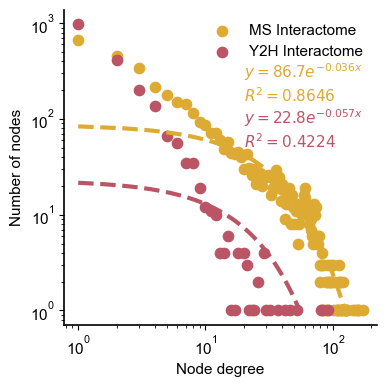

MS: a=86.734, b=-0.036, R²=0.8646
Y2H: a=22.826, b=-0.057, R²=0.4224


In [3]:
#PLOT DEGREE DISTRIBUTION ON A LOG-LOG SCALE USING EXPONENTIAL FIT
# =============================
# 1. Import Libraries & Set Global Aesthetics
# =============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

# Publication-style font and axis settings
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['xtick.labelsize'] = 11
plt.rcParams['ytick.labelsize'] = 11
plt.rcParams['legend.fontsize'] = 11
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False

# =============================
# 2. Define File Paths
# =============================
ms_edge_path = '/home/goel107/NCEMS/ANALYSIS/07_15_2025/The_Yeast_Interactome_edges.csv'
y2h_edge_path = '/home/goel107/NCEMS/ANALYSIS/07_15_2025/Y2H_union-clean_edges.csv'

# =============================
# 3. Helper Functions
# =============================
def split_interaction(s):
    parts = s.split(' (interacts with) ')
    return parts[0], parts[1]

def compute_degree_distribution(source_nodes, target_nodes):
    all_nodes = pd.concat([pd.Series(source_nodes), pd.Series(target_nodes)])
    degree_counts = all_nodes.value_counts().sort_index()
    unique_degrees, counts = np.unique(degree_counts.values, return_counts=True)
    return unique_degrees, counts

def exponential_fit(unique_degrees, counts, fit_range=None):
    mask = (unique_degrees > 0) & (counts > 0)
    if fit_range is not None:
        mask = mask & (unique_degrees >= fit_range[0]) & (unique_degrees <= fit_range[1])
    x = unique_degrees[mask]
    y = counts[mask]
    log_y = np.log(y)
    slope, intercept, r_value, p_value, std_err = linregress(x, log_y)
    a = np.exp(intercept)
    b = slope
    return a, b, r_value**2, x

# =============================
# 4. Load and Process Data
# =============================
# --- Mass Spec ---
df_ms = pd.read_csv(ms_edge_path)
unique_degrees_ms, counts_ms = compute_degree_distribution(df_ms['source'], df_ms['target'])

# --- Y2H ---
df_y2h = pd.read_csv(y2h_edge_path)
sources, targets = zip(*df_y2h['name'].map(split_interaction))
unique_degrees_y2h, counts_y2h = compute_degree_distribution(sources, targets)

# =============================
# 5. Publication-Quality Plotting
# =============================
fig, ax = plt.subplots(figsize=(4, 4))

# --- Plot all points ---
ax.scatter(unique_degrees_ms, counts_ms, s=55, color='#DDAA33', zorder=2, label='MS Interactome')
ax.scatter(unique_degrees_y2h, counts_y2h, s=55, color='#BB5566', zorder=2, label='Y2H Interactome')

# --- Fit exponential to MS (adjust fit range if needed) ---
a_ms, b_ms, R2_ms, x_fit_ms = exponential_fit(unique_degrees_ms, counts_ms, fit_range=None)
x_start_ms = 1
x_end_ms = -np.log(a_ms) / b_ms if b_ms != 0 else max(x_fit_ms)
x_plot_ms = np.linspace(x_start_ms, x_end_ms, 100)
y_plot_ms = a_ms * np.exp(b_ms * x_plot_ms)
ax.plot(x_plot_ms, y_plot_ms, '--', color='#DDAA33', lw=3, zorder=3)

# --- Annotate MS fit (no box) ---
eqn_str_ms = f"$y = {a_ms:.1f} e^{{{b_ms:.3f} x}}$\n$R^2 = {R2_ms:.4f}$"
ax.annotate(eqn_str_ms, xy=(20, 150), fontsize=11, fontfamily='Arial', color='#DDAA33', zorder=10, fontweight='bold')

# --- Fit exponential to Y2H (adjust fit range if needed) ---
a_y2h, b_y2h, R2_y2h, x_fit_y2h = exponential_fit(unique_degrees_y2h, counts_y2h, fit_range=None)
x_start_y2h = 1
x_end_y2h = -np.log(a_y2h) / b_y2h if b_y2h != 0 else max(x_fit_y2h)
x_plot_y2h = np.linspace(x_start_y2h, x_end_y2h, 100)
y_plot_y2h = a_y2h * np.exp(b_y2h * x_plot_y2h)
ax.plot(x_plot_y2h, y_plot_y2h, '--', color='#BB5566', lw=3, zorder=3)

# --- Annotate Y2H fit (no box) ---
eqn_str_y2h = f"$y = {a_y2h:.1f} e^{{{b_y2h:.3f} x}}$\n$R^2 = {R2_y2h:.4f}$"
ax.annotate(eqn_str_y2h, xy=(20, 50), fontsize=11, fontfamily='Arial', color='#BB5566', zorder=10, fontweight='bold')

# --- Axes ---
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Node degree', color='black')
ax.set_ylabel('Number of nodes', color='black')
#ax.set_title('Degree distribution', fontsize=17, loc='left', fontweight='bold')
ax.tick_params(axis='both', labelsize=11, colors='black')
ax.legend(loc='upper right', fontsize=11, frameon=False)
fig.tight_layout()

# --- Clean spines (Origin style) ---
for spine in ax.spines.values():
    spine.set_visible(False)
ax.spines['left'].set_visible(True)
ax.spines['bottom'].set_visible(True)
ax.spines['left'].set_color('black')
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_linewidth(1.2)
ax.spines['bottom'].set_linewidth(1.2)
ax.xaxis.set_ticks_position('bottom')
ax.yaxis.set_ticks_position('left')

# --- Save and/or show ---
#pd.DataFrame({'degree': unique_degrees_ms, 'count': counts_ms}).to_csv("ms_degree.csv", index=False)
#pd.DataFrame({'degree': unique_degrees_y2h, 'count': counts_y2h}).to_csv("y2h_degree.csv", index=False)
fig.savefig("/home/goel107/NCEMS/ANALYSIS/07_15_2025/FIGURE1/1D-log-log_plot(exponential-fit).svg", dpi=300, bbox_inches='tight')
plt.show()

# =============================
# 6. Output Fit Parameters (if needed)
# =============================
print(f"MS: a={a_ms:.3f}, b={b_ms:.3f}, R²={R2_ms:.4f}")
print(f"Y2H: a={a_y2h:.3f}, b={b_y2h:.3f}, R²={R2_y2h:.4f}")

In [4]:
from scipy.stats import linregress
import numpy as np

# ===============================
# Exponential fit: y = a * e^(b*x)
#   Linearized form: ln(y) = b*x + ln(a)
#   -> Correct for semi-log (log–linear) fits
# ===============================
def exponential_fit_linearx(x, y, fit_range=None):
    mask = (x > 0) & (y > 0)
    if fit_range is not None:
        mask &= (x >= fit_range[0]) & (x <= fit_range[1])
    x_fit = np.array(x)[mask]
    y_fit = np.array(y)[mask]
    log_y = np.log(y_fit)
    
    slope, intercept, r, p, se = linregress(x_fit, log_y)
    a = np.exp(intercept)
    b = slope
    R2 = r**2
    eqn = f"y = {a:.2f} * e^({b:.3f}x)"
    
    return a, b, R2, eqn, x_fit


# ===============================
# Power-law fit: y = a * x^b
#   Linearized form: ln(y) = b*ln(x) + ln(a)
#   -> Correct for log–log fits
# ===============================
def powerlaw_fit_logx(x, y, fit_range=None):
    mask = (x > 0) & (y > 0)
    if fit_range is not None:
        mask &= (x >= fit_range[0]) & (x <= fit_range[1])
    x_fit = np.array(x)[mask]
    y_fit = np.array(y)[mask]
    log_x = np.log(x_fit)
    log_y = np.log(y_fit)
    
    slope, intercept, r, p, se = linregress(log_x, log_y)
    a = np.exp(intercept)
    b = slope
    R2 = r**2
    eqn = f"y = {a:.2f} * x^{b:.3f}"
    
    return a, b, R2, eqn, x_fit


# ===============================
# Example usage on your data
# ===============================
a_exp, b_exp, R2_exp, eqn_exp, _ = exponential_fit_linearx(unique_degrees_ms, counts_ms)
a_pow, b_pow, R2_pow, eqn_pow, _ = powerlaw_fit_logx(unique_degrees_ms, counts_ms)

print(f"Exponential fit (semi-log): {eqn_exp}, R² = {R2_exp:.3f}")
print(f"Power-law fit (log–log):   {eqn_pow}, R² = {R2_pow:.3f}")

Exponential fit (semi-log): y = 86.73 * e^(-0.036x), R² = 0.865
Power-law fit (log–log):   y = 3274.24 * x^-1.545, R² = 0.882


In [5]:
#COMPUTE NUMBER OF NODE & EDGE 
# Set of valid filtered nodes from your EDA dataframe
valid_nodes = set(selected_columns['node'])

# Filtered MS nodes and edges
nodes_ms = set(df_ms['source']).union(df_ms['target'])
nodes_ms_filtered = nodes_ms.intersection(valid_nodes)

edges_ms = set(tuple(sorted([s, t])) for s, t in zip(df_ms['source'], df_ms['target']))
edges_ms_filtered = {e for e in edges_ms if e[0] in valid_nodes and e[1] in valid_nodes}

# Filtered Y2H nodes and edges
nodes_y2h = set(sources).union(targets)
nodes_y2h_filtered = nodes_y2h.intersection(valid_nodes)

edges_y2h = set(tuple(sorted([s, t])) for s, t in zip(sources, targets))
edges_y2h_filtered = {e for e in edges_y2h if e[0] in valid_nodes and e[1] in valid_nodes}

# --- Compute intersections ---
common_nodes = nodes_ms_filtered & nodes_y2h_filtered
common_edges = edges_ms_filtered & edges_y2h_filtered

print("========== NODE & EDGE STATISTICS ==========")
print(f"Number of nodes in MS (filtered): {len(nodes_ms_filtered)}")
print(f"Number of nodes in Y2H (filtered): {len(nodes_y2h_filtered)}")
print(f"Number of nodes common in both (filtered): {len(common_nodes)}\n")

print(f"Number of edges in MS (filtered): {len(edges_ms_filtered)}")
print(f"Number of edges in Y2H (filtered): {len(edges_y2h_filtered)}")
print(f"Number of edges common in both (filtered): {len(common_edges)}")

========== NODE & EDGE STATISTICS ==========
Number of nodes in MS (filtered): 3859
Number of nodes in Y2H (filtered): 1462
Number of nodes common in both (filtered): 1462

Number of edges in MS (filtered): 29490
Number of edges in Y2H (filtered): 1692
Number of edges common in both (filtered): 430


In [6]:
# COMPUTE ISOLATED NODES IN MS and Y2H THAT DO NOT INTERACT IN INTEARCTION NETWORK

# Filter MS edges
df_ms_filtered = df_ms[df_ms['source'].isin(valid_nodes) & df_ms['target'].isin(valid_nodes)]
# Filter Y2H edges
filtered_y2h_edges = [(s, t) for s, t in zip(sources, targets) if s in valid_nodes and t in valid_nodes]

# For MS
ms_edge_nodes = set(df_ms_filtered['source']).union(df_ms_filtered['target'])
ms_isolated_nodes = nodes_ms_filtered - ms_edge_nodes
print(f"MS isolated nodes (not in edges): {len(ms_isolated_nodes)}")
print(f"MS isolated nodes: {ms_isolated_nodes}")

# For Y2H
y2h_edge_nodes = set(s for s, t in filtered_y2h_edges).union(t for s, t in filtered_y2h_edges)
y2h_isolated_nodes = nodes_y2h_filtered - y2h_edge_nodes
print(f"Y2H isolated nodes (not in edges): {len(y2h_isolated_nodes)}")
print(f"Y2H isolated nodes: {y2h_isolated_nodes}")

MS isolated nodes (not in edges): 26
MS isolated nodes: {'YDL238C', 'YDR104C', 'YBL013W', 'YGR152C', 'YLR190W', 'YOR221C', 'YPR081C', 'YPR129W', 'YGR295C', 'YGR052W', 'YKL113C', 'YOR193W', 'YGL185C', 'YDR300C', 'YHR063C', 'YKR099W', 'YDR132C', 'YNL154C', 'YPL097W', 'YPL112C', 'YDL173W', 'YPL072W', 'YDL146W', 'YNL053W', 'YGL126W', 'YDR400W'}
Y2H isolated nodes (not in edges): 151
Y2H isolated nodes: {'YDL204W', 'YML018C', 'YPL218W', 'YDR240C', 'YDR222W', 'YIL001W', 'YHR140W', 'YGL087C', 'YGR278W', 'YDR061W', 'YJL200C', 'YDR145W', 'YNL279W', 'YOL020W', 'YIR025W', 'YNL007C', 'YMR275C', 'Q0085', 'YJR010C-A', 'YHR096C', 'YNL098C', 'YKL038W', 'YHR197W', 'YLR006C', 'YJR009C', 'YIL053W', 'YIL124W', 'YOR281C', 'YDR052C', 'YGR140W', 'YDR116C', 'YBR123C', 'YEL032W', 'YOR264W', 'YPR159W', 'YGL030W', 'YDL238C', 'YBR038W', 'YKR010C', 'YGL086W', 'YIL026C', 'YOL088C', 'YMR280C', 'YGR074W', 'YNL216W', 'YLR323C', 'YDR159W', 'YLR032W', 'YJR125C', 'YDL073W', 'YER134C', 'YBR102C', 'YOR308C', 'YMR316W', 'YP

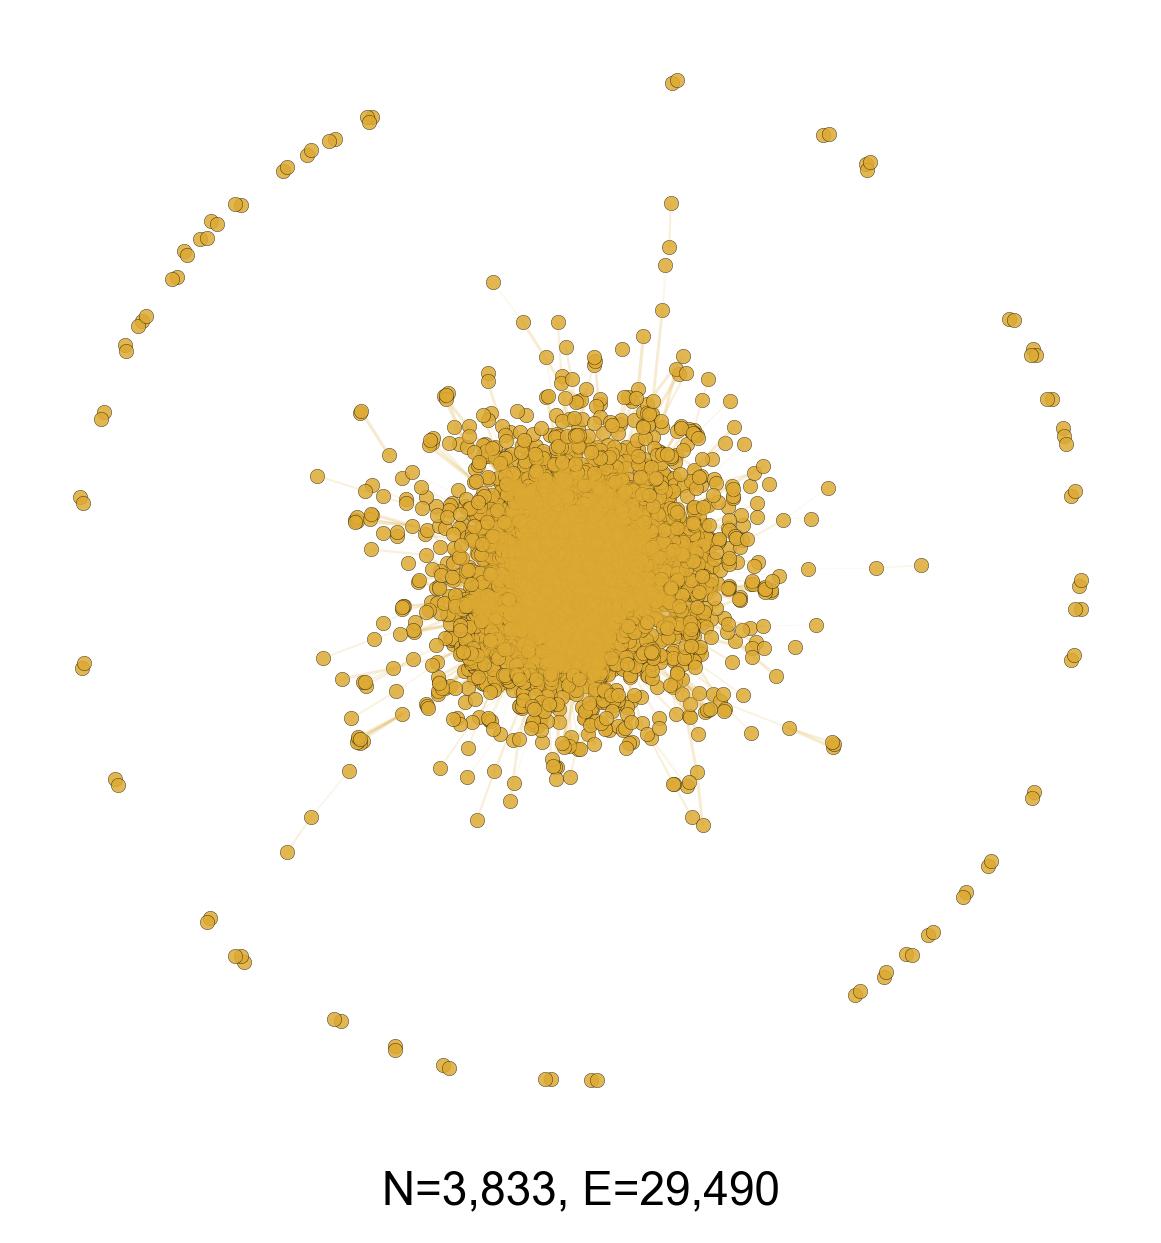

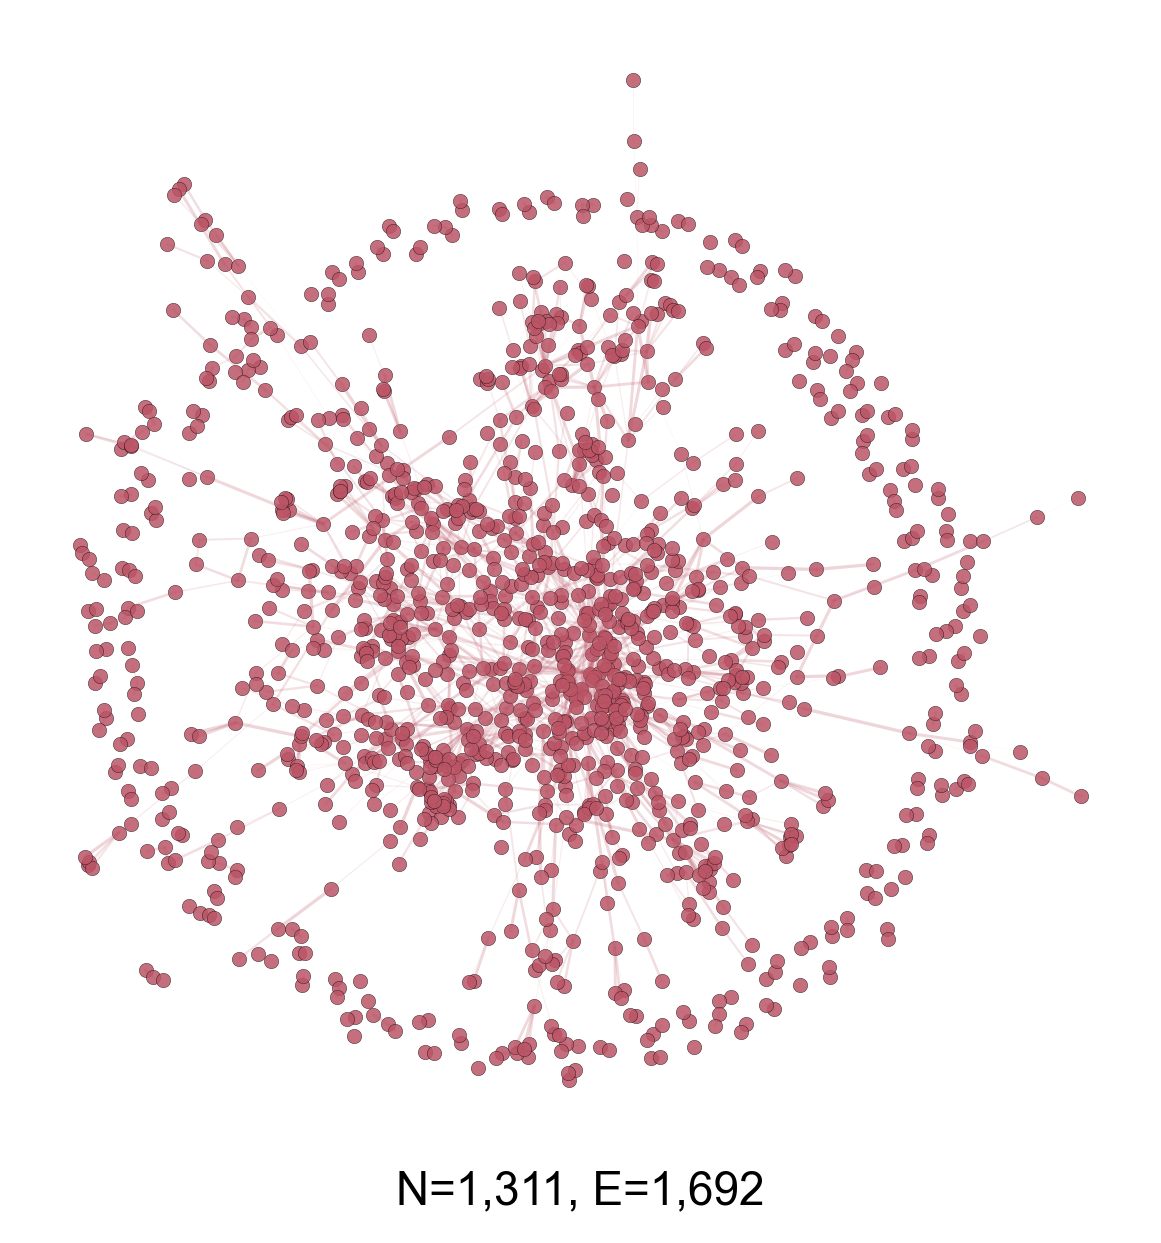

In [7]:
#PLOT FULL INTERACTION NETWORKS
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np

# =========================================
# 0. GLOBAL VISUAL SETTINGS
# =========================================
plt.rcParams.update({
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "axes.titlesize": 14,
    "axes.titlepad": 25,
    "font.family": "sans-serif",
    "font.sans-serif": "Arial",
    "figure.facecolor": "white",
    "axes.facecolor": "white"
})

# =========================================
# 1. FILTERED INTERACTOMES
# =========================================
valid_nodes = set(selected_columns['node'])

# --- MS Interactome ---
df_ms_filtered = df_ms[df_ms['source'].isin(valid_nodes) & df_ms['target'].isin(valid_nodes)]
G_ms = nx.from_pandas_edgelist(df_ms_filtered, 'source', 'target')
ms_nodes_full, ms_edges_full = G_ms.number_of_nodes(), G_ms.number_of_edges()

# --- Y2H Interactome ---
filtered_y2h_edges = [(s, t) for s, t in zip(sources, targets) if s in valid_nodes and t in valid_nodes]
G_y2h = nx.Graph()
G_y2h.add_edges_from(filtered_y2h_edges)
y2h_nodes_full, y2h_edges_full = G_y2h.number_of_nodes(), G_y2h.number_of_edges()


# =========================================
# 2. FUNCTION FOR HIGH-QUALITY DRAWING
# =========================================
def plot_high_quality_network(G, title, color, save_name, legend_label, node_size=12):
    """Draws a high-quality dense network with visual depth and smooth rendering."""
    fig, ax = plt.subplots(figsize=(4, 4))

    # --- Stable, visually balanced layout ---
    pos = nx.spring_layout(G, seed=42, k=0.12, iterations=100)

    # --- Compute edge layering (depth effect): darker for background, lighter for front ---
    edges = np.array(list(G.edges()))
    np.random.shuffle(edges)  # randomize order for organic layering
    n_edges = len(edges)
    alphas = np.linspace(0.05, 0.25, n_edges)  # gradual transparency
    widths = np.linspace(0.1, 0.8, n_edges)    # variable edge width

    # --- Draw edges with gradual depth ---
    for (i, (u, v)) in enumerate(edges):
        ax.plot(
            [pos[u][0], pos[v][0]],
            [pos[u][1], pos[v][1]],
            color=color,
            lw=widths[i],
            alpha=alphas[i],
            solid_capstyle='round',
            zorder=i
        )

    # --- Draw nodes with subtle halo effect ---
    nx.draw_networkx_nodes(
        G, pos, ax=ax,
        node_size=node_size,
        node_color=color,
        alpha=0.85,
        linewidths=0.1,
        edgecolors='black'
    )

    # --- Title & Legend ---
    # --- Hide title and legend ---
    ax.axis('off')

    # --- Print N and E below the figure ---
    fig.text(0.5, -0.02, f"N={G.number_of_nodes():,}, E={G.number_of_edges():,}", ha='center', fontsize=11)

    # --- Tight layout & save ---
    plt.tight_layout()
    plt.savefig(save_name, bbox_inches='tight', facecolor='white')
    plt.show()


# =========================================
# 3. DRAW FULL INTERACTOMES
# =========================================
plot_high_quality_network(
    G_ms,
    title=f"",
    color="#DDAA33",
    save_name="/home/goel107/NCEMS/ANALYSIS/07_15_2025/FIGURE1/1A-ms_full_interactome.svg",
    legend_label=""
)

plot_high_quality_network(
    G_y2h,
    title=f"",
    color="#BB5566",
    save_name="/home/goel107/NCEMS/ANALYSIS/07_15_2025/FIGURE1/1A-y2h_full_interactome.svg",
    legend_label=""
)

# =========================================
# 4. LARGEST CONNECTED COMPONENTS (LCC)
# =========================================
#largest_cc_ms = max(nx.connected_components(G_ms), key=len)
#G_ms_lcc = G_ms.subgraph(largest_cc_ms).copy()
#ms_nodes_lcc, ms_edges_lcc = G_ms_lcc.number_of_nodes(), G_ms_lcc.number_of_edges()

#largest_cc_y2h = max(nx.connected_components(G_y2h), key=len)
#G_y2h_lcc = G_y2h.subgraph(largest_cc_y2h).copy()
#y2h_nodes_lcc, y2h_edges_lcc = G_y2h_lcc.number_of_nodes(), G_y2h_lcc.number_of_edges()

#plot_high_quality_network(
#    G_ms_lcc,
#    title=f"IPMS Interactome (LCC)\nN={ms_nodes_lcc:,}, E={ms_edges_lcc:,}",
#    color="#DDAA33",
#    save_name="/home/goel107/NCEMS/ANALYSIS/07_15_2025/FIGURE1/1A-ms_lcc_comparison.svg",
#    legend_label="IPMS (MS)"
#)

#plot_high_quality_network(
#    G_y2h_lcc,
#    title=f"Y2H Interactome (LCC)\nN={y2h_nodes_lcc:,}, E={y2h_edges_lcc:,}",
#    color="#BB5566",
#    save_name="/home/goel107/NCEMS/ANALYSIS/07_15_2025/FIGURE1/1A-y2h_lcc_comparison.svg",
#    legend_label="Y2H"
#)

# =========================================
# 5. PRINT STATS
# =========================================
#print(f"MS LCC: {ms_nodes_lcc:,} nodes, {ms_edges_lcc:,} edges")
#print(f"Y2H LCC: {y2h_nodes_lcc:,} nodes, {y2h_edges_lcc:,} edges")

In [8]:
#COMPUTE NODES AND EDGES IN THE MS & Y2H OVERLAP NETWORK
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt

# Assume selected_columns is already loaded with filtered proteins
valid_nodes = set(selected_columns['node'])

# === 1. Filter edges to keep only those with both nodes in valid_nodes ===

# Filter MS edges
df_ms_filtered = df_ms[df_ms['source'].isin(valid_nodes) & df_ms['target'].isin(valid_nodes)]

# Filter Y2H edges
filtered_y2h_edges = [(s, t) for s, t in zip(sources, targets) if s in valid_nodes and t in valid_nodes]

# === 2. Make a set of edges (as sorted tuples) for both filtered networks ===

edges_ms = set(tuple(sorted([row['source'], row['target']])) for _, row in df_ms_filtered.iterrows())
edges_y2h = set(tuple(sorted([s, t])) for s, t in filtered_y2h_edges)

# === 3. Intersection (common edges only) ===
edges_intersection = edges_ms & edges_y2h

print(f"Number of common edges (interactions): {len(edges_intersection)}")

# === 4. Build the consensus/intersection network ===
G_overlap = nx.Graph()
G_overlap.add_edges_from(edges_intersection)

print(f"Number of nodes in overlap network: {G_overlap.number_of_nodes()}")

# === 5. Extract largest connected component (LCC) ===
if G_overlap.number_of_nodes() > 0:
    largest_cc_overlap = max(nx.connected_components(G_overlap), key=len)
    G_overlap_lcc = G_overlap.subgraph(largest_cc_overlap).copy()
    print(f"Largest connected component size: {G_overlap_lcc.number_of_nodes()} nodes, {G_overlap_lcc.number_of_edges()} edges")
else:
    print("No overlap between MS and Y2H networks!")

# === 6. Plot the largest connected component of overlap network ===
#if G_overlap.number_of_nodes() > 0:
    #plt.figure(figsize=(8, 8))
    #pos = nx.spring_layout(G_overlap_lcc, seed=42, k=0.18)
    #nx.draw_networkx_nodes(G_overlap_lcc, pos, node_size=40, alpha=0.8, node_color="#8888FF")
    #nx.draw_networkx_edges(G_overlap_lcc, pos, width=0.6, alpha=0.5, edge_color="#333377")
    #plt.title("Largest Connected Component: Intersection of MS & Y2H (Filtered)", fontsize=15)
    #plt.axis("off")
    #plt.tight_layout()
    #plt.show()

# List proteins in intersection network
proteins_in_overlap = list(G_overlap.nodes())
print(f"Total proteins in overlap network: {len(proteins_in_overlap)}")
print(proteins_in_overlap[:10])

Number of common edges (interactions): 430
Number of nodes in overlap network: 657
Largest connected component size: 10 nodes, 12 edges
Total proteins in overlap network: 657
['YBR255W', 'YIL106W', 'YBR152W', 'YGR075C', 'YDR205W', 'YNR039C', 'YNR010W', 'YOR174W', 'YGR086C', 'YKL142W']


In [9]:
#COMPUTE HUBS IN EACH NETWORK
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt

# Assuming selected_columns, df_ms, sources, targets are defined
# Set of valid filtered nodes from your EDA dataframe
valid_nodes = set(selected_columns['node'])

# Step 1: Filter edges to keep only those with both nodes in valid_nodes
df_ms_filtered = df_ms[df_ms['source'].isin(valid_nodes) & df_ms['target'].isin(valid_nodes)]
filtered_y2h_edges = [(s, t) for s, t in zip(sources, targets) if s in valid_nodes and t in valid_nodes]

# Step 2: Create edge sets (sorted tuples for undirected edges) and remove self-loops
edges_ms = {tuple(sorted([row['source'], row['target']])) for _, row in df_ms_filtered.iterrows() if row['source'] != row['target']}
edges_y2h = {tuple(sorted([s, t])) for s, t in filtered_y2h_edges if s != t}

# Step 3: Compute edge union and intersection
edges_union = edges_ms | edges_y2h
edges_intersection = edges_ms & edges_y2h
edge_overlap_percent = (len(edges_intersection) / len(edges_union)) * 100 if edges_union else 0

# Step 4: Build graphs
G_ms = nx.from_pandas_edgelist(df_ms_filtered, 'source', 'target')
G_y2h = nx.Graph()
G_y2h.add_edges_from(filtered_y2h_edges)

# Step 5: Compute descriptors (degree and betweenness; add other 7 metrics if needed)
descriptors_ms = pd.DataFrame({
    'node': list(G_ms.nodes()),
    'degree': [G_ms.degree(n) for n in G_ms.nodes()],
    'betweenness': nx.betweenness_centrality(G_ms).values()
})
descriptors_y2h = pd.DataFrame({
    'node': list(G_y2h.nodes()),
    'degree': [G_y2h.degree(n) for n in G_y2h.nodes()],
    'betweenness': nx.betweenness_centrality(G_y2h).values()
})

# Step 6: Identify common nodes
common_nodes = set(descriptors_ms['node']) & set(descriptors_y2h['node'])

# Step 7: Filter descriptors to common nodes for fair comparison
descriptors_ms = descriptors_ms[descriptors_ms['node'].isin(common_nodes)]
descriptors_y2h = descriptors_y2h[descriptors_y2h['node'].isin(common_nodes)]

# Step 8: Define hubs (top 10% by degree)
num_nodes = len(common_nodes)
top_percent = 0.10
hub_threshold_ms = descriptors_ms['degree'].quantile(1 - top_percent)
hub_threshold_y2h = descriptors_y2h['degree'].quantile(1 - top_percent)

hubs_ms = descriptors_ms[descriptors_ms['degree'] >= hub_threshold_ms]['node'].tolist()
hubs_y2h = descriptors_y2h[descriptors_y2h['degree'] >= hub_threshold_y2h]['node'].tolist()

# Step 9: Compute hub intersection and union
common_hubs = set(hubs_ms) & set(hubs_y2h)
all_hubs = set(hubs_ms) | set(hubs_y2h)
hub_overlap_percentage = (len(common_hubs) / len(all_hubs)) * 100 if len(all_hubs) > 0 else 0

# Step 10: Print all statistics
print("=== Network Edge Statistics ===")
print(f"Number of edges in MS (filtered): {len(edges_ms)}")
print(f"Number of edges in Y2H (filtered): {len(edges_y2h)}")
print(f"Number of edges in union: {len(edges_union)}")
print(f"Number of edges in intersection: {len(edges_intersection)}")
print(f"Edge overlap percentage (intersection/union): {edge_overlap_percent:.2f}%")

print("\n=== Hub Statistics ===")
print(f"Number of common nodes: {num_nodes}")
print(f"Number of hubs in MS: {len(hubs_ms)}")
print(f"Number of hubs in Y2H: {len(hubs_y2h)}")
print(f"Number of common hubs (intersection): {len(common_hubs)}")
print(f"Number of all relevant hubs (union): {len(all_hubs)}")
print(f"Hub overlap percentage (intersection/union): {hub_overlap_percentage:.2f}%")
print(f"Example MS hubs: {hubs_ms[:5]}")
print(f"Example Y2H hubs: {hubs_y2h[:5]}")

=== Network Edge Statistics ===
Number of edges in MS (filtered): 29490
Number of edges in Y2H (filtered): 1556
Number of edges in union: 30616
Number of edges in intersection: 430
Edge overlap percentage (intersection/union): 1.40%

=== Hub Statistics ===
Number of common nodes: 1303
Number of hubs in MS: 138
Number of hubs in Y2H: 155
Number of common hubs (intersection): 11
Number of all relevant hubs (union): 282
Hub overlap percentage (intersection/union): 3.90%
Example MS hubs: ['YKR066C', 'YLR421C', 'YLR216C', 'YJL001W', 'YMR024W']
Example Y2H hubs: ['YJL112W', 'YMR124W', 'YAL032C', 'YDR416W', 'YDR448W']


Total hubs analyzed: 282
Similar hubs (Jaccard > 0.3): 8
MS dominant dissimilar hubs: 183
Y2H dominant dissimilar hubs: 80
Percentage of hubs with similar connectivity: 2.84%
Similar hubs (nodes): ['YKR037C', 'YPL031C', 'YBR135W', 'YIL033C', 'YNL124W', 'YHR068W', 'YJR102C', 'YNL078W']

Preview of similarity metrics (first 10 rows):
        node  degree_ms  degree_y2h  degree_diff  betweenness_ms  \
0    YPR135W         43           3     0.229221        0.006819   
1    YER127W         56           1     0.346970        0.000012   
2    YNL088W         55           1     0.340476        0.000473   
3    YCR077C         58           4     0.309957        0.000987   
4    YPL094C         15          19     0.219264        0.000086   
5    YHR114W          2          11     0.170346        0.000153   
6    YDL081C         71           3     0.411039        0.002330   
7    YLR432W         10           7     0.051732        0.000372   
8    YIL144W          8           8     0.081385      

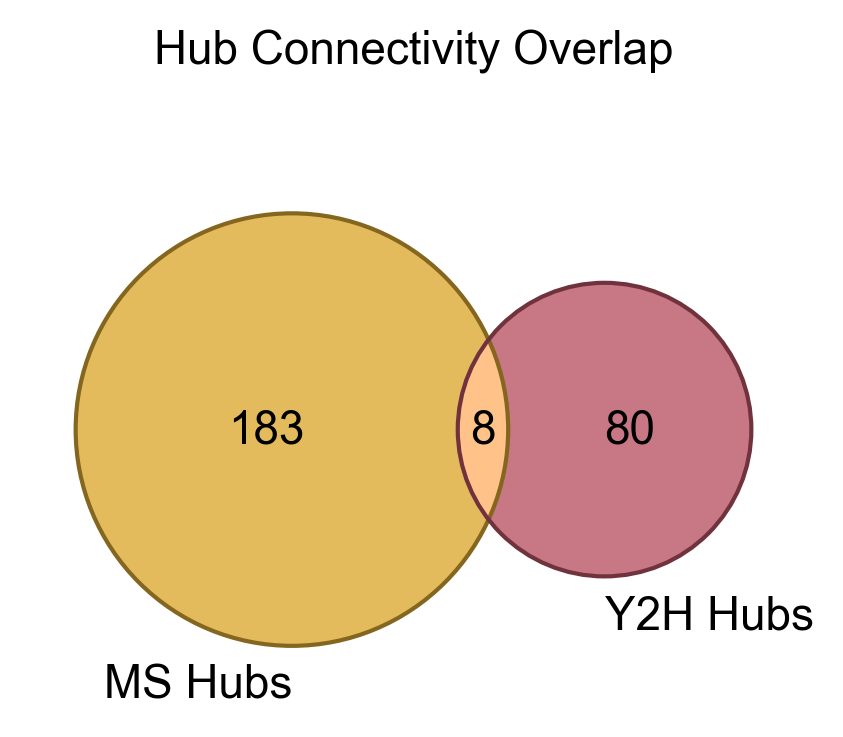

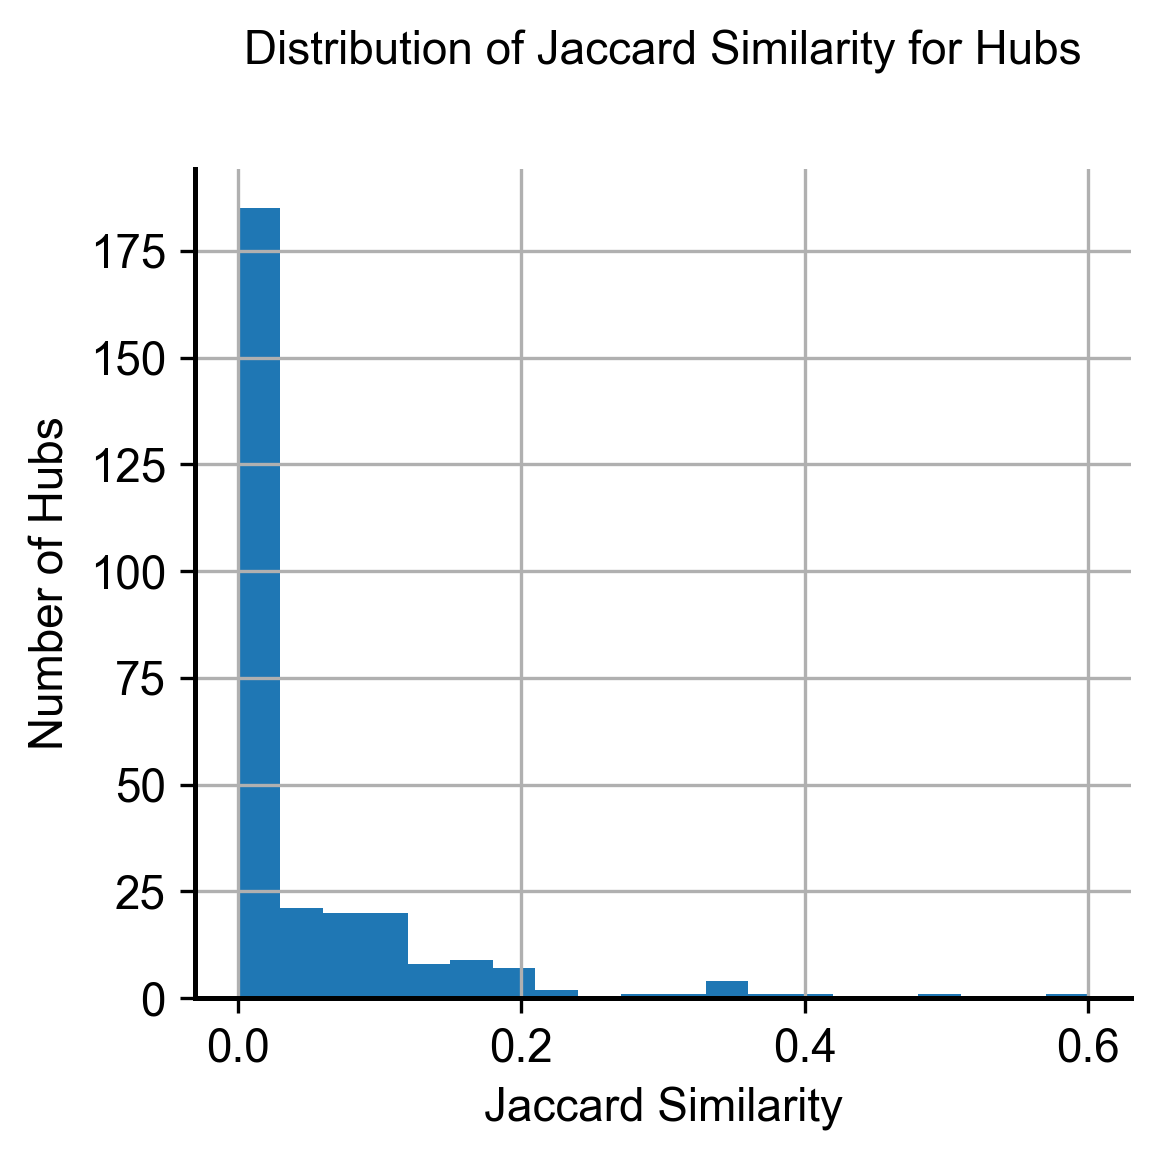

In [10]:
#COMPUTE HUB CONNECTIVITY OVERLAP BASED ON JACCARD SIMILARITY INDEX
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib_venn import venn2, venn2_circles
from matplotlib.colors import to_rgb, rgb_to_hsv, hsv_to_rgb
import numpy as np

# Set Global Aesthetics
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['xtick.labelsize'] = 11
plt.rcParams['ytick.labelsize'] = 11
plt.rcParams['legend.fontsize'] = 11
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False

# Function to darken a color
def darken_color(color, factor=0.6):
    rgb = to_rgb(color)
    hsv = rgb_to_hsv(rgb)
    # Reduce value (brightness) to darken
    hsv = (hsv[0], hsv[1], hsv[2] * factor)
    return hsv_to_rgb(hsv)

# Assuming G_ms, G_y2h, descriptors_ms, descriptors_y2h, all_hubs are defined
# Ensure descriptors_ms and descriptors_y2h have 'node', 'degree', 'betweenness' for common nodes
# Create a DataFrame to store similarity metrics for all hubs
similarity_df = pd.DataFrame(all_hubs, columns=['node'])

# Merge degree and betweenness from both networks
similarity_df = similarity_df.merge(
    descriptors_ms[['node', 'degree', 'betweenness']],
    on='node', how='left', suffixes=('', '_ms')
).merge(
    descriptors_y2h[['node', 'degree', 'betweenness']],
    on='node', how='left', suffixes=('_ms', '_y2h')
)

# Fill NaN for non-hubs (e.g., hub in MS but not Y2H)
similarity_df.fillna({'degree_ms': 0, 'betweenness_ms': 0, 'degree_y2h': 0, 'betweenness_y2h': 0}, inplace=True)

# Normalize metrics (divide by max in each network)
max_degree_ms = descriptors_ms['degree'].max()
max_degree_y2h = descriptors_y2h['degree'].max()
max_betweenness_ms = descriptors_ms['betweenness'].max()
max_betweenness_y2h = descriptors_y2h['betweenness'].max()
similarity_df['norm_degree_ms'] = similarity_df['degree_ms'] / max_degree_ms
similarity_df['norm_degree_y2h'] = similarity_df['degree_y2h'] / max_degree_y2h
similarity_df['norm_betweenness_ms'] = similarity_df['betweenness_ms'] / max_betweenness_ms
similarity_df['norm_betweenness_y2h'] = similarity_df['betweenness_y2h'] / max_betweenness_y2h

# Compute differences
similarity_df['degree_diff'] = abs(similarity_df['norm_degree_ms'] - similarity_df['norm_degree_y2h'])
similarity_df['betweenness_diff'] = abs(similarity_df['norm_betweenness_ms'] - similarity_df['norm_betweenness_y2h'])

# Compute Jaccard similarity for neighbor overlap
def jaccard_similarity(g1, g2, node):
    try:
        neighbors1 = set(g1.neighbors(node))
        neighbors2 = set(g2.neighbors(node))
        intersection = len(neighbors1 & neighbors2)
        union = len(neighbors1 | neighbors2)
        return intersection / union if union > 0 else 0
    except nx.NetworkXError:
        return 0  # If node not in graph, assume no overlap

similarity_df['jaccard'] = similarity_df['node'].apply(lambda x: jaccard_similarity(G_ms, G_y2h, x))

# Define "similar" hubs with thresholds
degree_threshold = 0.2
betweenness_threshold = 0.2
jaccard_threshold = 0.3  # Matches your result of 8 similar hubs
similarity_df['is_similar'] = (
    (similarity_df['degree_diff'] < degree_threshold) &
    (similarity_df['betweenness_diff'] < betweenness_threshold) &
    (similarity_df['jaccard'] > jaccard_threshold)
)

# Calculate counts
total_hubs = len(similarity_df)  # Should be 282
similar_hubs = similarity_df['is_similar'].sum()

# Classify dissimilar hubs based on degree dominance
similarity_df['is_ms_dominant'] = (similarity_df['degree_ms'] > similarity_df['degree_y2h']) & (~similarity_df['is_similar'])
similarity_df['is_y2h_dominant'] = (similarity_df['degree_y2h'] > similarity_df['degree_ms']) & (~similarity_df['is_similar'])
ms_dominant_hubs = similarity_df['is_ms_dominant'].sum()
y2h_dominant_hubs = similarity_df['is_y2h_dominant'].sum()

# Output statistics
print(f"Total hubs analyzed: {total_hubs}")
print(f"Similar hubs (Jaccard > {jaccard_threshold}): {similar_hubs}")
print(f"MS dominant dissimilar hubs: {ms_dominant_hubs}")
print(f"Y2H dominant dissimilar hubs: {y2h_dominant_hubs}")
print(f"Percentage of hubs with similar connectivity: {(similar_hubs / total_hubs) * 100:.2f}%")
print(f"Similar hubs (nodes): {similarity_df[similarity_df['is_similar']]['node'].tolist()}")
print("\nPreview of similarity metrics (first 10 rows):")
print(similarity_df[['node', 'degree_ms', 'degree_y2h', 'degree_diff', 'betweenness_ms', 'betweenness_y2h', 'betweenness_diff', 'jaccard', 'is_similar']].head(10))

# Save to CSV for inspection (optional)
#similarity_df.to_csv('hub_similarity_metrics.csv', index=False)

# Colors
color_ms = '#DDAA33'
color_y2h = '#BB5566'
# Darken colors for outlines
ms_edge_color = darken_color(color_ms, factor=0.6)
y2h_edge_color = darken_color(color_y2h, factor=0.6)

# Venn diagram
fig_venn = plt.figure(figsize=(3, 3))
ax_venn = fig_venn.add_subplot(111)
# Calculate sets for Venn diagram
ms_hubs = similarity_df[similarity_df['degree_ms'] > 0]['node'].count()  # All MS hubs
y2h_hubs = similarity_df[similarity_df['degree_y2h'] > 0]['node'].count()  # All Y2H hubs
overlap = similar_hubs  # Similar hubs are in both MS and Y2H
ms_only = ms_dominant_hubs  # MS-dominant dissimilar hubs
y2h_only = y2h_dominant_hubs  # Y2H-dominant dissimilar hubs
# Create Venn diagram
venn = venn2(subsets=(ms_only, y2h_only, overlap), set_labels=('MS Hubs', 'Y2H Hubs'), set_colors=(color_ms, color_y2h), alpha=0.8, ax=ax_venn)
venn.get_label_by_id('10').set_text(str(ms_only))  # MS only
venn.get_label_by_id('01').set_text(str(y2h_only))  # Y2H only
venn.get_label_by_id('11').set_text(str(overlap))  # Common
c = venn2_circles(subsets=(ms_only, y2h_only, overlap), linestyle='solid', linewidth=1, ax=ax_venn)
c[0].set_edgecolor(ms_edge_color)  # Darker MS outline
c[1].set_edgecolor(y2h_edge_color)  # Darker Y2H outline
# Customize labels
for text in venn.set_labels:
    if text: text.set_fontsize(11)
for text in venn.subset_labels:
    if text: text.set_fontsize(11)
ax_venn.set_title(f'Hub Connectivity Overlap', fontsize=11)
plt.tight_layout()
plt.savefig('/home/goel107/NCEMS/ANALYSIS/07_15_2025/FIGURE1/1E-venn-diagram.svg', dpi=300, bbox_inches='tight', format='pdf')
plt.show()

# Jaccard histogram
fig_hist = plt.figure(figsize=(4, 4))
ax_hist = fig_hist.add_subplot(111)
similarity_df['jaccard'].hist(bins=20, ax=ax_hist)
ax_hist.set_xlabel('Jaccard Similarity', fontsize=11)
ax_hist.set_ylabel('Number of Hubs', fontsize=11)
ax_hist.set_title('Distribution of Jaccard Similarity for Hubs', fontsize=11)
plt.tight_layout()
#plt.savefig('jaccard_histogram.pdf', dpi=300, bbox_inches='tight', format='pdf')
plt.show()